#### Group-level anomaly analysis

In [18]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))
from config import raw_data, control_data, external_data, raw_kyiv, filtered_data, daily_data

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
import warnings
warnings.filterwarnings("ignore")

In [20]:
daily_path = daily_data
external_path = external_data

In [21]:
war_date = pd.Timestamp("2022-02-24")

window_months = 30
start = war_date - pd.DateOffset(months=0)
end = war_date + pd.DateOffset(months=window_months)

In [22]:
attack_threshold = 50 

top_n = 10
ma_window = 7 

In [23]:
private_cols = ["msg_count", "audio_count"]
public_cols = ["post_count", "comment_count", "reaction_count"]

In [24]:
files_cols = [
    ('donor_daily_message_count.csv', 'donor_daily_message_count', 'msg_count'),
    ('donor_daily_audio.csv', 'donor_daily_audio_count', 'audio_count'),
    ('donor_daily_posts.csv', 'donor_daily_post_count', 'post_count'),
    ('donor_daily_comments.csv', 'donor_daily_comment_count', 'comment_count'),
    ('donor_daily_reactions.csv', 'donor_daily_reaction_count','reaction_count'),
]

dfs = []
for fname, src_col, dst_col in files_cols:
    tmp = pd.read_csv(daily_path / fname)
    tmp['date'] = pd.to_datetime(tmp['date'])
    tmp = tmp.rename(columns={src_col: dst_col})[['donation_id', 'date', dst_col]]
    dfs.append(tmp)

df = reduce(lambda l, r: pd.merge(l, r, on=['donation_id', 'date'], how='outer'), dfs)
df = df.fillna(0)
df['date'] = pd.to_datetime(df['date'])
df = df[(df['date'] >= start) & (df['date'] <= end)]

print(f'Donors: {df["donation_id"].nunique()}')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Shape: {df.shape}')


Donors: 24
Date range: 2022-02-24 → 2024-08-24
Shape: (20463, 7)


#### Percentile normalization per donor

In [25]:
feat_cols = private_cols + public_cols

for col in feat_cols:
    df[col + "_pct"] = df.groupby("donation_id")[col].rank(pct=True)

pct_cols = [c + "_pct" for c in feat_cols]


#### Aggregate per day (mean across donors)

In [26]:
daily_agg = df.groupby("date")[pct_cols].mean().reset_index()

priv_pct_cols = [c + "_pct" for c in private_cols]
pub_pct_cols = [c + "_pct" for c in public_cols]

daily_agg["private_score"] = daily_agg[priv_pct_cols].mean(axis=1)
daily_agg["public_score"] = daily_agg[pub_pct_cols].mean(axis=1)

daily_agg["private_z"] = (daily_agg["private_score"] - daily_agg["private_score"].mean()) / daily_agg["private_score"].std()
daily_agg["public_z"] = (daily_agg["public_score"] - daily_agg["public_score"].mean()) / daily_agg["public_score"].std()

print(f"Daily aggregated: {daily_agg.shape}")
daily_agg[["date", "private_score", "public_score", "private_z", "public_z"]].head()


Daily aggregated: (913, 10)


,date,private_score,public_score,private_z,public_z
0,2022-02-24,0.630492,0.583232,2.623903,2.684280
1,2022-02-25,0.607424,0.578822,2.157043,2.541447
2,2022-02-26,0.596816,0.558713,1.942346,1.890144
3,2022-02-27,0.502942,0.538500,0.042502,1.235487
4,2022-02-28,0.463728,0.522438,-0.751117,0.715282


In [27]:
attacks = pd.read_csv(external_path / 'massive_attacks_by_category.csv', low_memory=False)
attacks["date"] = pd.to_datetime(attacks["date_start"])
attacks = attacks[(attacks["date"] >= start) & (attacks["date"] <= end)]

daily_agg = daily_agg.merge(attacks[["date", "Total"]], on="date", how="left")
daily_agg["Total"] = daily_agg["Total"].fillna(0)
daily_agg["is_massive"] = daily_agg["Total"] >= attack_threshold

print(f"Massive attack days (Total >= {attack_threshold}): {daily_agg['is_massive'].sum()}")


Massive attack days (Total >= 50): 33


#### Top anomalous days by z-score

In [28]:
top_private = daily_agg.nlargest(top_n, "private_z")[["date", "private_score", "private_z", "Total", "is_massive"]].reset_index(drop=True)
top_public = daily_agg.nlargest(top_n, "public_z")[["date", "public_score",  "public_z",  "Total", "is_massive"]].reset_index(drop=True)
bot_private = daily_agg.nsmallest(top_n, "private_z")[["date", "private_score", "private_z", "Total", "is_massive"]].reset_index(drop=True)
bot_public = daily_agg.nsmallest(top_n, "public_z")[["date", "public_score",  "public_z",  "Total", "is_massive"]].reset_index(drop=True)

for label, df_top in [("Private High", top_private), ("Public High", top_public),
                       ("Private Low",  bot_private), ("Public Low",  bot_public)]:
    col = "private_score" if "Private" in label else "public_score"
    print(f"Top {top_n} anomalous days — {label}:")
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    display(df_top)
    print(f"Massive attacks on these days: {df_top['is_massive'].sum()}/{top_n}\n")


Top 10 anomalous days — Private High:


,date,private_score,private_z,Total,is_massive
0,2022-04-04,0.669339,3.410090,0.0,False
1,2022-07-01,0.665755,3.337555,0.0,False
2,2022-03-24,0.640031,2.816959,0.0,False
3,2022-07-28,0.637934,2.774509,0.0,False
4,2022-04-11,0.636712,2.749782,0.0,False
5,2022-02-24,0.630492,2.623903,0.0,False
6,2022-07-02,0.630483,2.623713,0.0,False
7,2022-09-12,0.625355,2.519926,0.0,False
8,2023-01-13,0.622307,2.458238,0.0,False
9,2022-03-31,0.621125,2.434319,0.0,False


Massive attacks on these days: 0/10

Top 10 anomalous days — Public High:


,date,public_score,public_z,Total,is_massive
0,2024-07-31,0.642092,4.590623,89.0,True
1,2024-05-26,0.613133,3.652700,45.0,False
2,2024-08-02,0.609132,3.523116,0.0,False
3,2024-04-28,0.594743,3.057086,4.0,False
4,2024-08-01,0.592869,2.996408,7.0,False
5,2023-08-29,0.591982,2.967669,0.0,False
6,2023-07-24,0.589498,2.887200,0.0,False
7,2022-08-29,0.584600,2.728562,0.0,False
8,2022-02-24,0.583232,2.684280,0.0,False
9,2023-12-30,0.580962,2.610733,0.0,False


Massive attacks on these days: 1/10

Top 10 anomalous days — Private Low:


,date,private_score,private_z,Total,is_massive
0,2024-02-22,0.379372,-2.458356,11.0,False
1,2022-12-20,0.381089,-2.423603,0.0,False
2,2023-04-26,0.381545,-2.414367,0.0,False
3,2023-09-14,0.386726,-2.309512,0.0,False
4,2024-01-10,0.392871,-2.185147,0.0,False
5,2023-06-05,0.396635,-2.108966,0.0,False
6,2023-09-12,0.400167,-2.037494,0.0,False
7,2022-11-07,0.401579,-2.008911,0.0,False
8,2024-04-08,0.402155,-1.997265,24.0,False
9,2023-03-01,0.402642,-1.987396,0.0,False


Massive attacks on these days: 0/10

Top 10 anomalous days — Public Low:


,date,public_score,public_z,Total,is_massive
0,2023-02-08,0.394249,-3.436494,0.0,False
1,2022-12-12,0.413602,-2.809689,0.0,False
2,2023-02-17,0.422194,-2.531437,0.0,False
3,2023-02-07,0.427466,-2.360692,0.0,False
4,2023-10-17,0.427547,-2.358046,0.0,False
5,2022-11-07,0.432305,-2.203937,0.0,False
6,2023-01-10,0.433777,-2.156263,0.0,False
7,2022-12-20,0.434084,-2.146331,0.0,False
8,2023-01-23,0.434275,-2.140163,0.0,False
9,2022-11-22,0.434431,-2.135093,0.0,False


Massive attacks on these days: 0/10



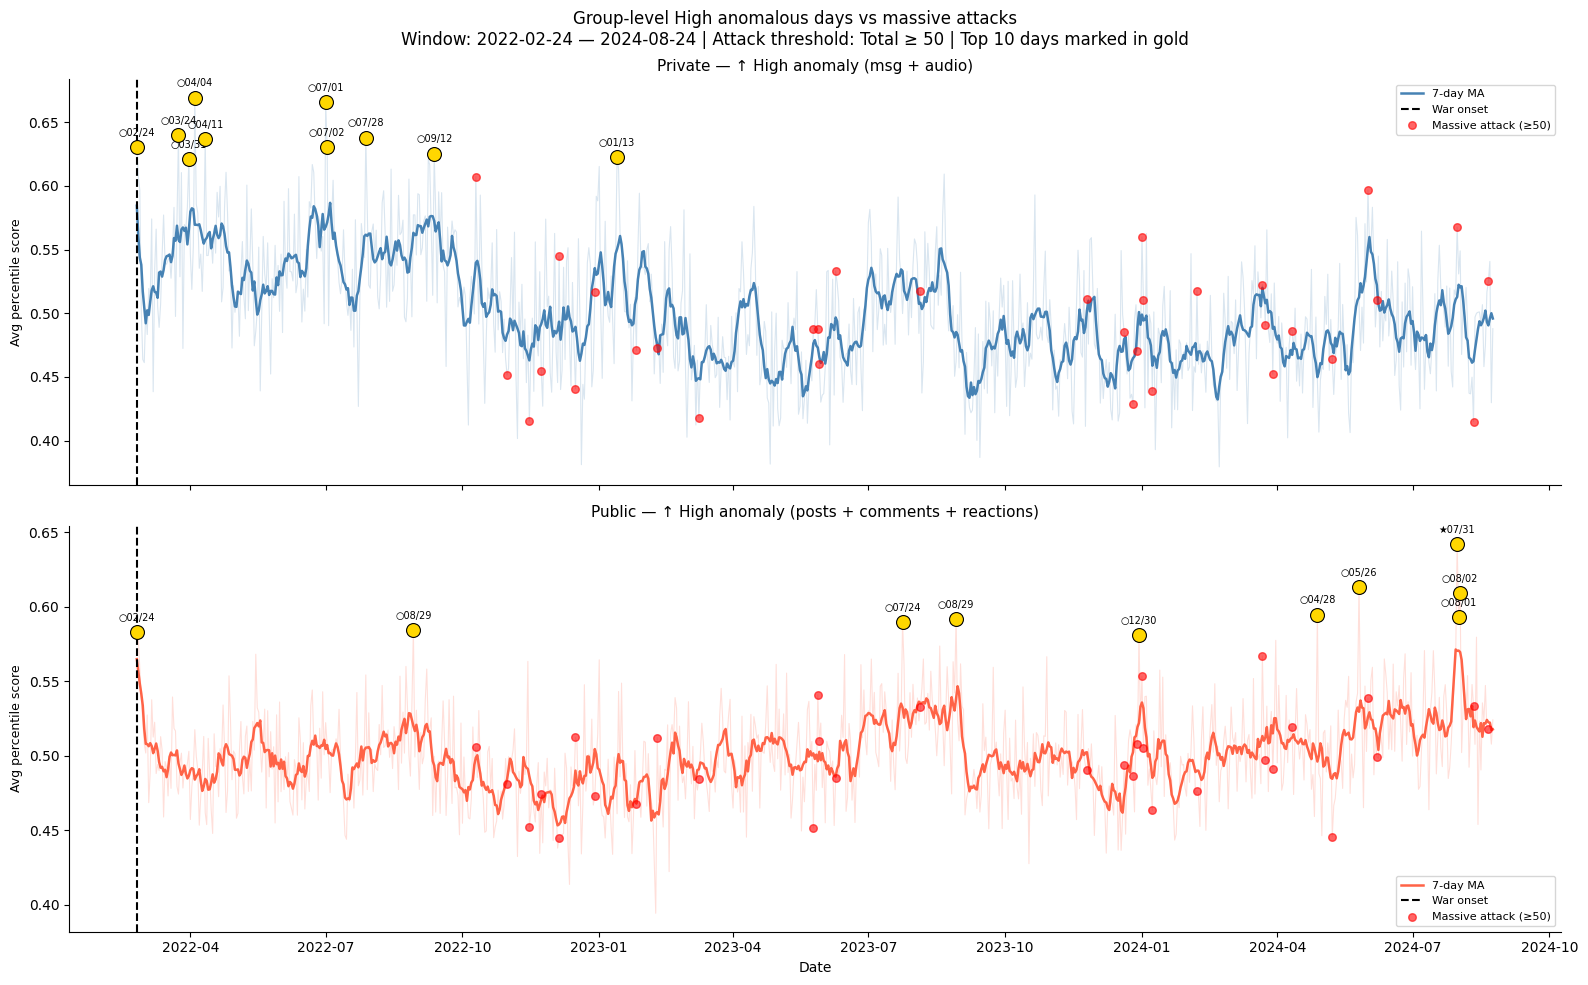

In [29]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

for ax, score_col, top_days, title, color in [
    (ax1, "private_score", top_private, "Private — ↑ High anomaly (msg + audio)", "steelblue"),
    (ax2, "public_score",  top_public, "Public — ↑ High anomaly (posts + comments + reactions)", "tomato"),
]:
    ma = daily_agg[score_col].rolling(ma_window, center=True, min_periods=1).mean()
    ax.plot(daily_agg["date"], daily_agg[score_col], color=color, alpha=0.2, linewidth=0.8)
    ax.plot(daily_agg["date"], ma, color=color, linewidth=1.8, label=f"{ma_window}-day MA")
    ax.axvline(war_date, color="black", linestyle="--", linewidth=1.5, label="War onset")
    attack_days_plot = daily_agg[daily_agg["is_massive"]]
    ax.scatter(attack_days_plot["date"], attack_days_plot[score_col],
               color="red", s=30, zorder=5, label=f"Massive attack (≥{attack_threshold})", alpha=0.6)
    for _, row in top_days.iterrows():
        day_data = daily_agg[daily_agg["date"] == row["date"]]
        if not day_data.empty:
            ax.scatter(row["date"], day_data[score_col].values[0],
                       color="gold", s=100, zorder=6, edgecolors="black", linewidths=0.8)
            marker = "★" if row["is_massive"] else "○"
            ax.annotate(f"{marker}{row['date'].strftime('%m/%d')}",
                        xy=(row["date"], day_data[score_col].values[0]),
                        xytext=(0, 8), textcoords="offset points",
                        fontsize=7, ha="center")
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Avg percentile score", fontsize=9)
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

ax2.set_xlabel("Date", fontsize=10)
plt.suptitle(
    f"Group-level High anomalous days vs massive attacks\n"
    f"Window: {start.date()} — {end.date()} | Attack threshold: Total ≥ {attack_threshold} | Top {top_n} days marked in gold",
    fontsize=12
)
plt.tight_layout()
plt.show()


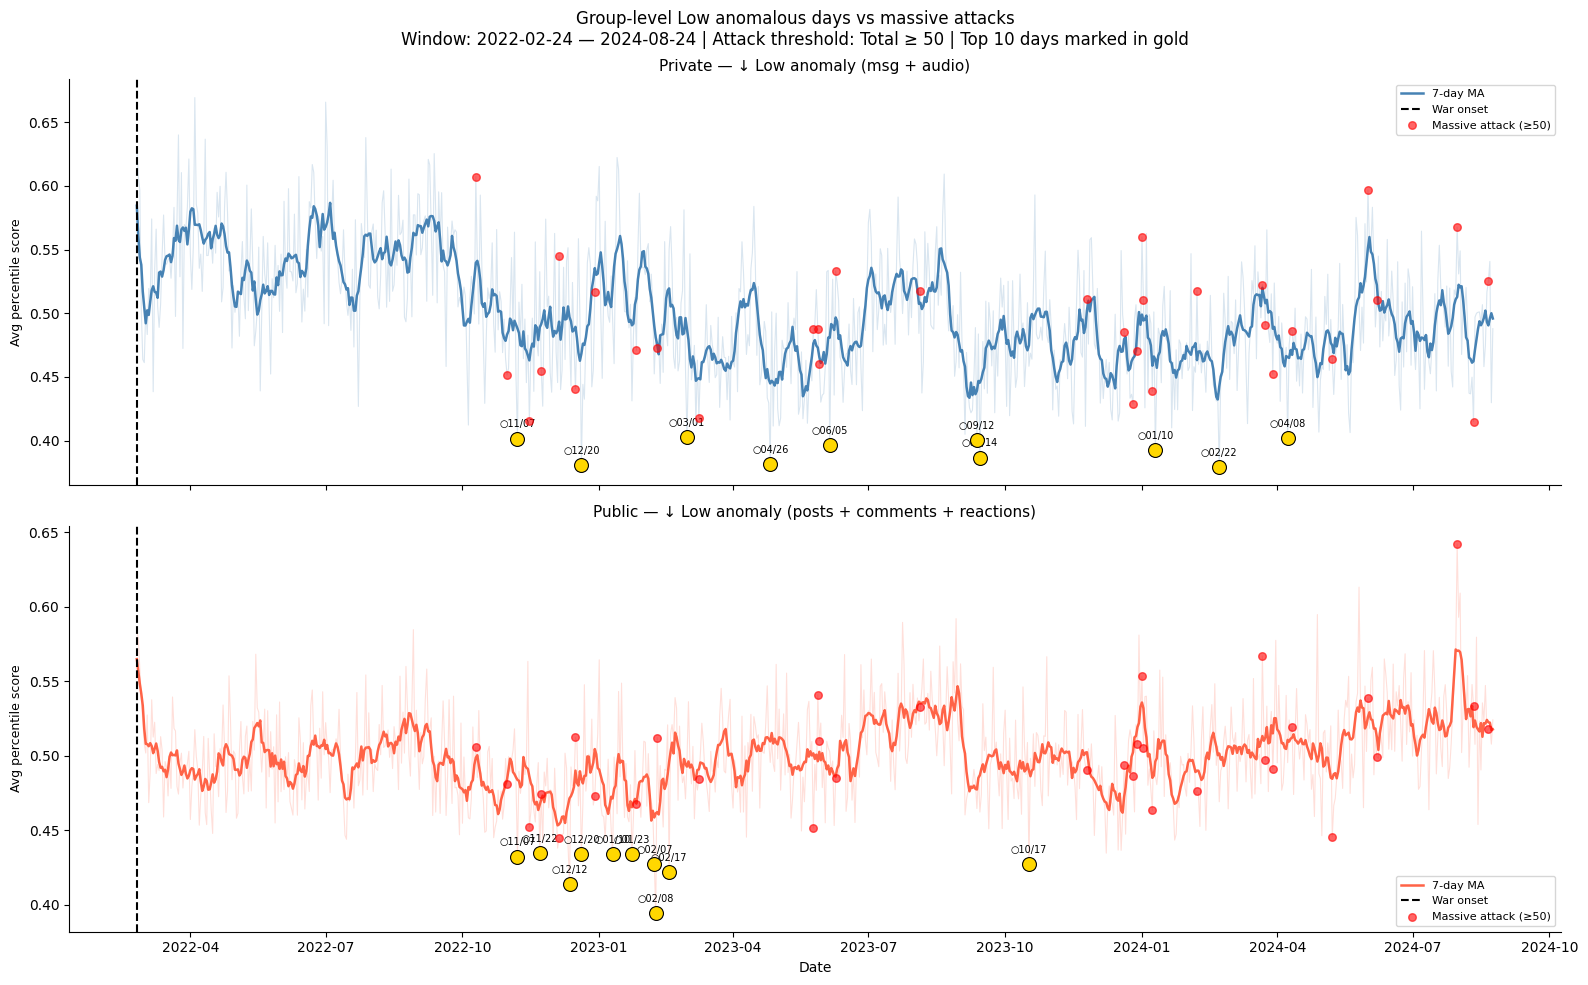

In [30]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

for ax, score_col, top_days, title, color in [
    (ax1, "private_score", bot_private, "Private — ↓ Low anomaly (msg + audio)", "steelblue"),
    (ax2, "public_score", bot_public, "Public — ↓ Low anomaly (posts + comments + reactions)", "tomato"),
]:
    ma = daily_agg[score_col].rolling(ma_window, center=True, min_periods=1).mean()
    ax.plot(daily_agg["date"], daily_agg[score_col], color=color, alpha=0.2, linewidth=0.8)
    ax.plot(daily_agg["date"], ma, color=color, linewidth=1.8, label=f"{ma_window}-day MA")
    ax.axvline(war_date, color="black", linestyle="--", linewidth=1.5, label="War onset")
    attack_days_plot = daily_agg[daily_agg["is_massive"]]
    ax.scatter(attack_days_plot["date"], attack_days_plot[score_col],
               color="red", s=30, zorder=5, label=f"Massive attack (≥{attack_threshold})", alpha=0.6)
    for _, row in top_days.iterrows():
        day_data = daily_agg[daily_agg["date"] == row["date"]]
        if not day_data.empty:
            ax.scatter(row["date"], day_data[score_col].values[0],
                       color="gold", s=100, zorder=6, edgecolors="black", linewidths=0.8)
            marker = "★" if row["is_massive"] else "○"
            ax.annotate(f"{marker}{row['date'].strftime('%m/%d')}",
                        xy=(row["date"], day_data[score_col].values[0]),
                        xytext=(0, 8), textcoords="offset points",
                        fontsize=7, ha="center")
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Avg percentile score", fontsize=9)
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

ax2.set_xlabel("Date", fontsize=10)
plt.suptitle(
    f"Group-level Low anomalous days vs massive attacks\n"
    f"Window: {start.date()} — {end.date()} | Attack threshold: Total ≥ {attack_threshold} | Top {top_n} days marked in gold",
    fontsize=12
)
plt.tight_layout()
plt.show()